## Analyze contacts data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Convert atomic contact points to residue contact points

Annotate residue occurrences with contact information

In [2]:
rc = pd.read_csv("../../generated/contacts/residue_contacts_all.tsv", sep="\t")
rc.head()

,pdb_id,chain_type,ab_chain,ab_resnum,ab_icode,ab_resname,natomcontacts,nrescontacts,contact
0,8veb,heavy,G,1,,GLN,0.0,0.0,0
1,8veb,heavy,G,2,,VAL,0.0,0.0,0
2,8veb,heavy,G,3,,GLN,0.0,0.0,0
3,8veb,heavy,G,4,,LEU,0.0,0.0,0
4,8veb,heavy,G,5,,LEU,0.0,0.0,0


In [3]:
df = pd.read_csv("../../generated/data cleanup/ab_ag_filtered_pdb.tsv", sep='\t')
#rc = pd.read_csv("../generated/contacts/residue_contacts_all.tsv", sep='\t')

In [4]:
df.head(3).T

,0,1,2
pdb,8veb,8ved,8vee
Hchain,G,H,H
Lchain,I,L,L
model,0,0,0
antigen_chain,E,A,A
antigen_type,protein,protein,protein
antigen_name,hemagglutinin,hemagglutinin,hemagglutinin
compound,Cryo-EM structure of antibody T5-1E08 in compl...,Cryo-EM structure of antibody T5-1E11 in compl...,Cryo-EM structure of antibody T5-1E08 in compl...
organism,Homo sapiens; Influenza A virus,Homo sapiens; Influenza A virus,Homo sapiens; Influenza A virus
heavy_species,homo sapiens,homo sapiens,homo sapiens


For our analysis we first add the `species` and `method` columns from `df` to `rc` using `merge`. 

- we use `rc`as left data frame, and `df`as right data frame
- which column(s)/keys in the left and right data frame contain the id on which we want to join?
  `left_on = "pdb_id", right_on = "pdb"`
- select only the necessary columns from `right`
- what kind of join do we want to perform?  `how = "left"` A left join in pandas means all rows from the left DataFrame (the one you start with) are kept, even if there’s no match in the right DataFrame. If there’s a matching row in the right DataFrame, it adds that info. If there’s no match, you get NaN (missing values) for the right DataFrame's columns.

For better overwiew, we will order the DataFrame by residue number first `ab_resnum`, and then by insertion code within each residue number `ab_icode`.

In [5]:
m = rc.merge(df.get(["pdb", "species", "method"]), 
             how = "left", 
             left_on = "pdb_id", 
             right_on = "pdb")
m = m.assign(ab_res = m["ab_resnum"].astype(str)+m["ab_icode"])

m = m.sort_values(["ab_resnum", "ab_icode"])

m.head()

,pdb_id,chain_type,ab_chain,ab_resnum,ab_icode,ab_resname,natomcontacts,nrescontacts,contact,pdb,species,method,ab_res
0,8veb,heavy,G,1,,GLN,0.0,0.0,0,8veb,Influenza A,ELECTRON MICROSCOPY,1
128,8veb,light,I,1,,ASP,0.0,0.0,0,8veb,Influenza A,ELECTRON MICROSCOPY,1
233,8ved,heavy,H,1,,GLN,0.0,0.0,0,8ved,Influenza A,ELECTRON MICROSCOPY,1
359,8ved,light,L,1,,ASP,0.0,0.0,0,8ved,Influenza A,ELECTRON MICROSCOPY,1
471,8vee,heavy,H,1,,GLN,0.0,0.0,0,8vee,Influenza A,ELECTRON MICROSCOPY,1


turn m, booleans/strings/numbers into clean floats, so that we can plot and analyze the "contact" column reliably

In [6]:
def to_float(x):
    if x in [True, 'True', 'true']:
        return 1.0
    if x in [False, 'False', 'false']:
        return 0.0
    try:
        return float(x)
    except:
        return np.nan   # or handle as you wish

import numpy as np
m["contact"] = m["contact"].apply(to_float)
print(m["contact"].unique())
print(m["contact"].dtype)

[0. 1.]
float64


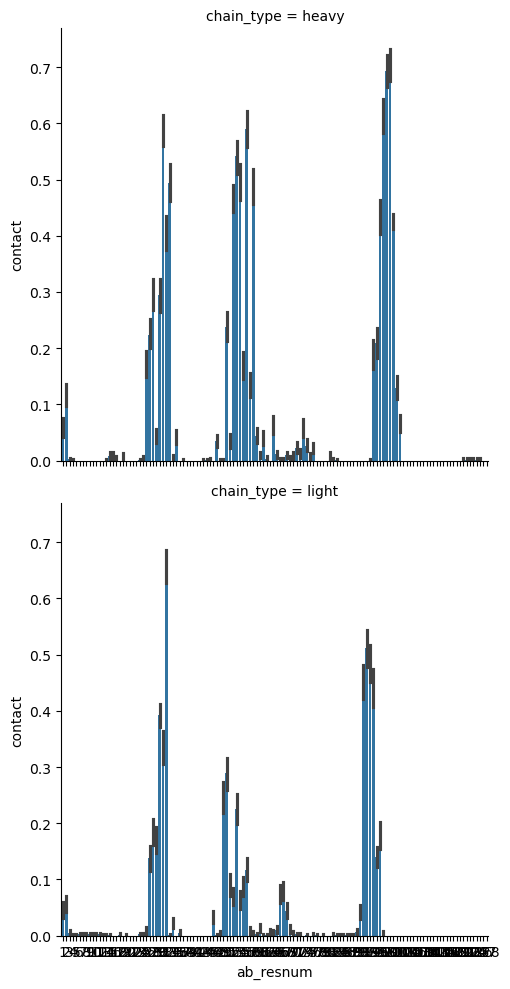

In [7]:
sns.catplot(m, x = "ab_resnum", y = "contact", kind = "bar", row = "chain_type")

In the plots abow we can see that there a clearly three peaks which mark parts in the ab-structure residuechain that bind to the antigens. We can make an educated guess that those parts are the CDRs of the antibody. Still, there are some other peaks, besides the CDRs which means that in some structures there are residues in contact that dont belong to the CDRs, those we would like to a closer look at...

### Look at CDR loops

contact propensity = (# times residue appears in contact) / (# times residue appears in loop)

Create barplots of `ab_resnum` vs `contact` for regions around CDR regions for heavy and light chain. Use a different color (hue) for the three species.

You can find the CDR regions at http://www.bioinf.org.uk/abs/info.html 


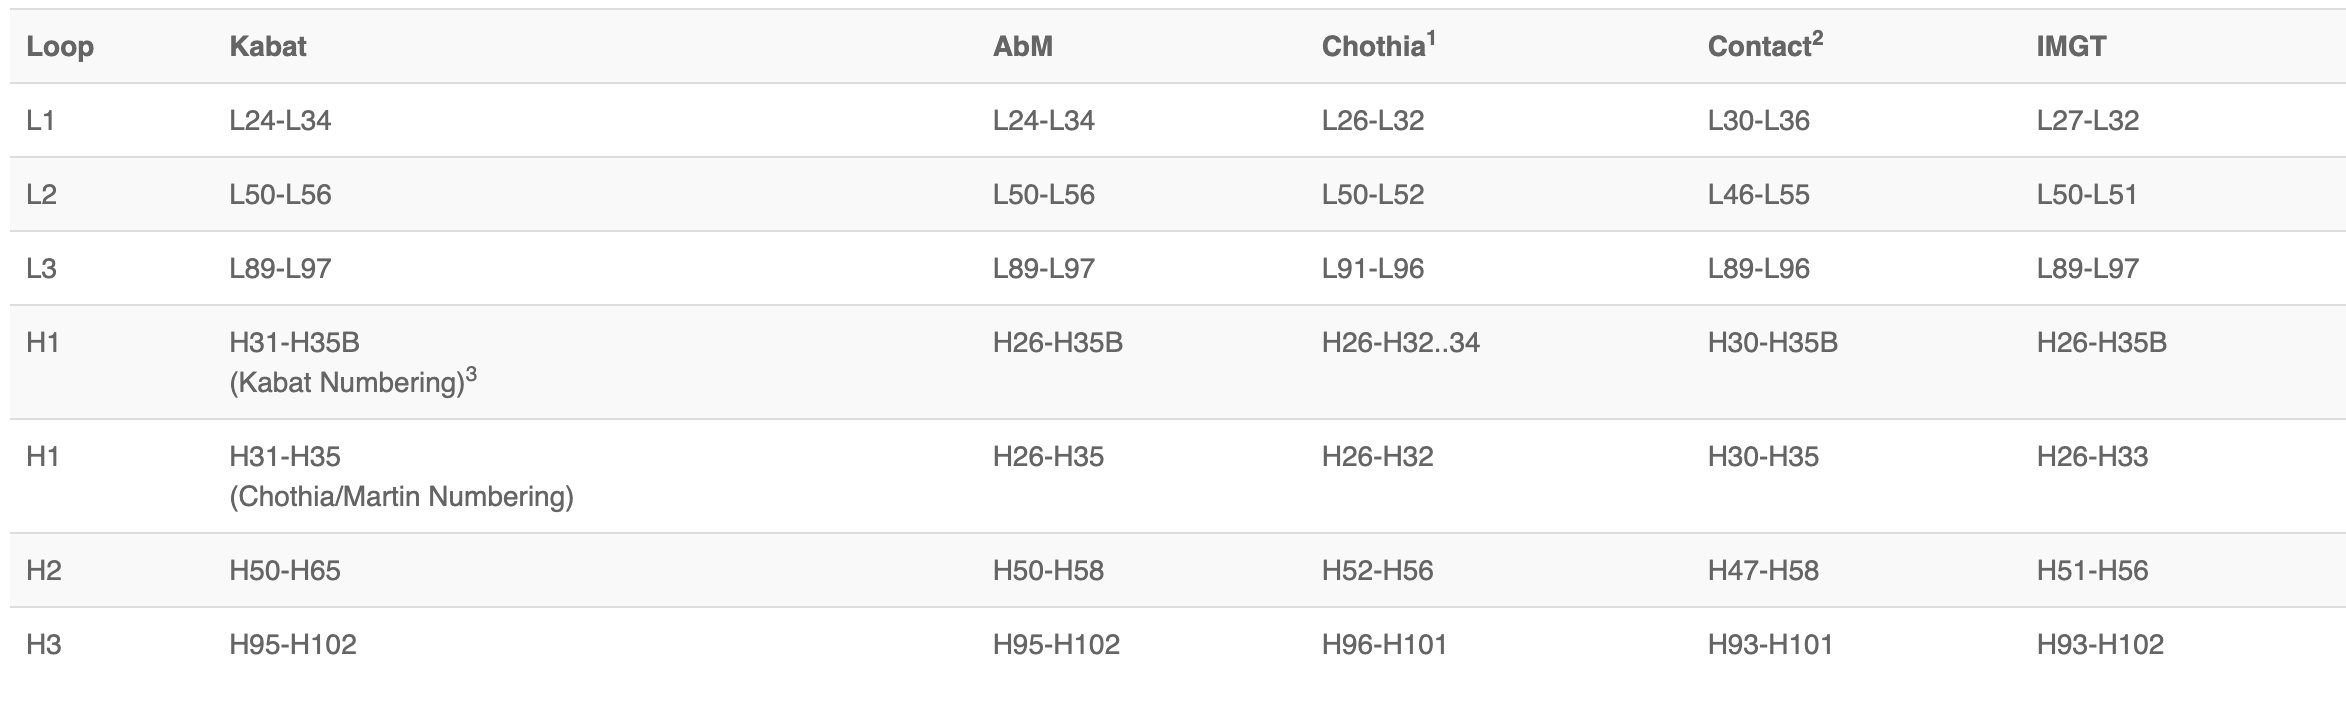

The CDRs are defined differently, depending on the renumbering format. We use Chotia renumbered PDB files for our project. 

now lets taka a closer look at each of the CDR regions

float64
[0. 1.]


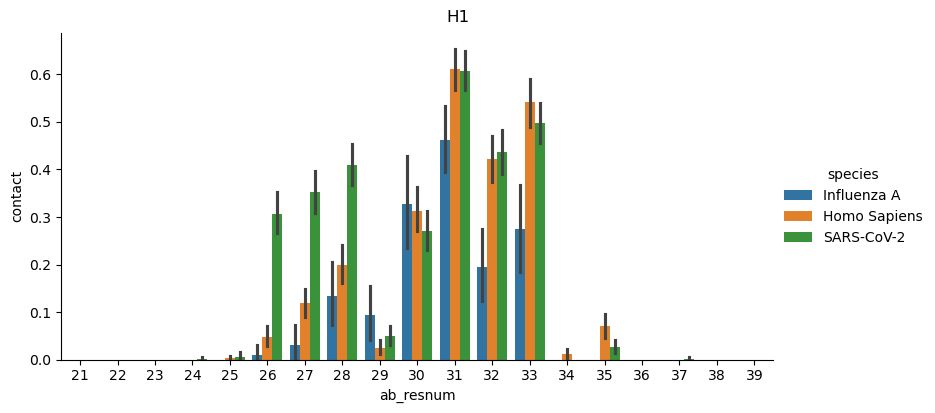

In [ ]:

g = sns.catplot(data = m.query("chain_type == 'heavy' and 20 < ab_resnum < 40"), 
            x = "ab_resnum", # od ab_res for icode
            y = "contact",
            kind = "bar",
            hue = "species",
            #row = "method",
            errorbar = ("ci", 95),
            height = 4, aspect = 2)


g.fig.suptitle("H1", y=1.02) 

this barplot is especially interesting because here we can see that SARS-CoV-2-abs bind more often at residues 26 - 28 than the other ab-types 

Text(0.5, 1.02, 'H2')

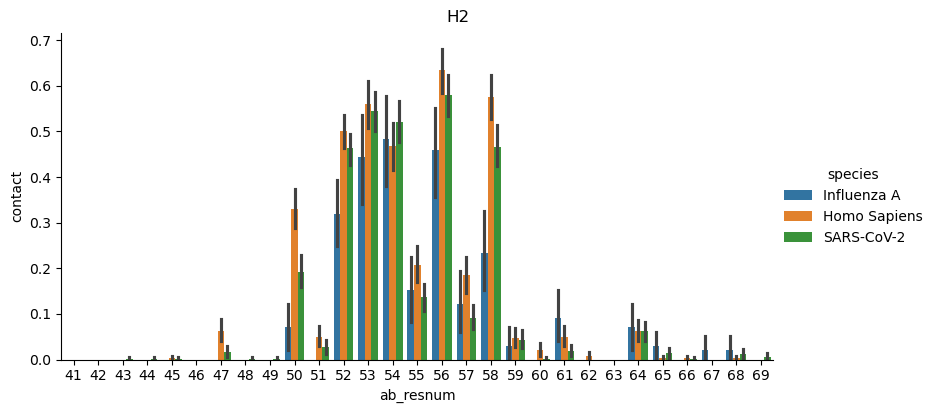

In [10]:
g = sns.catplot(data = m.query("chain_type == 'heavy' and 40 < ab_resnum < 70"), 
            x = "ab_resnum", 
            y = "contact",
            hue = "species",
            kind = "bar",
            height = 4, aspect = 2)

g.fig.suptitle("H2", y=1.02) 

Whats interesting here is that the CDR-H2 region is defined between residues 52-56, but hera all ab-types form contacts also outside of this residues

Text(0.5, 1.0, 'H3')

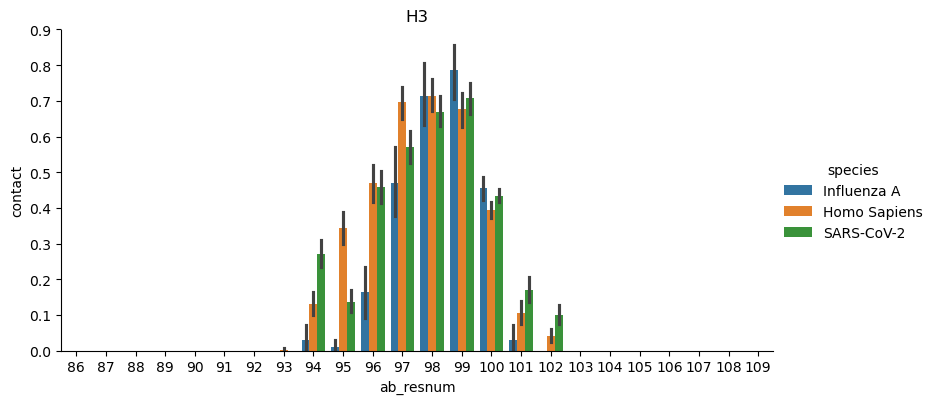

In [11]:
sns.catplot(data = m.query("chain_type == 'heavy' and 85 < ab_resnum < 110"), 
            x = "ab_resnum", 
            y = "contact",
            hue = "species",
            kind = "bar",
            height = 4, aspect = 2)
plt.title("H3")

Text(0.5, 1.0, 'L1')

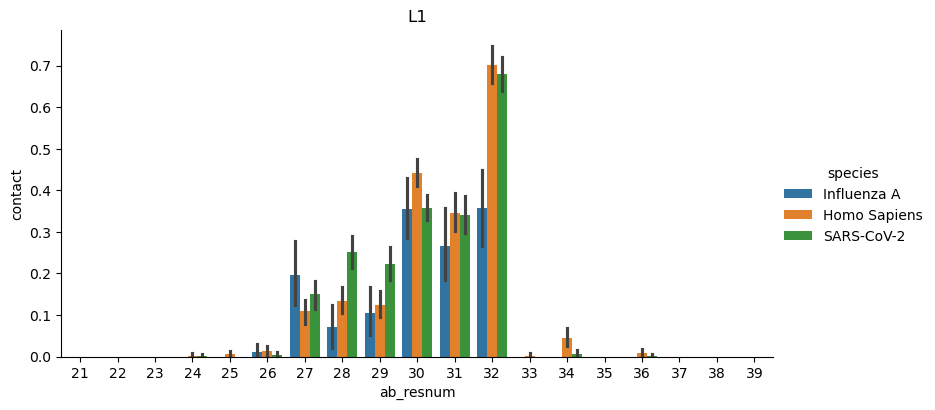

In [12]:
sns.catplot(data = m.query("chain_type == 'light' and 20 < ab_resnum < 40"), 
            x = "ab_resnum", 
            y = "contact",
            kind = "bar",
            hue = "species",
            height = 4, aspect = 2)
plt.title("L1")

Text(0.5, 1.0, 'L2')

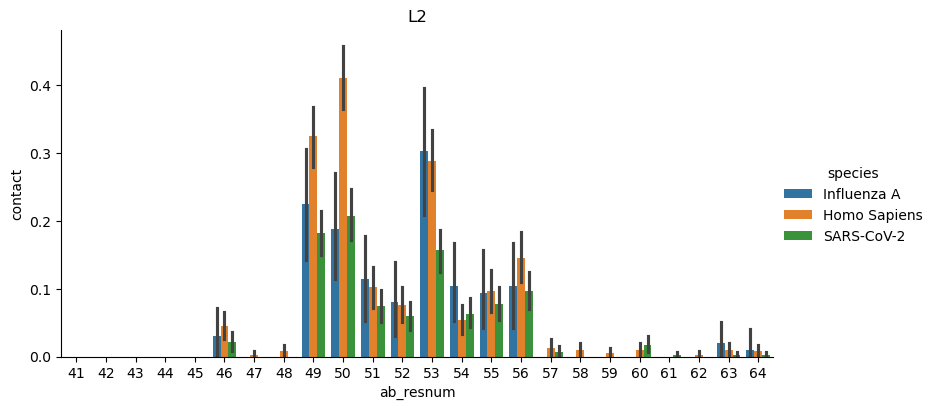

In [13]:
sns.catplot(data = m.query("chain_type == 'light' and 40 < ab_resnum < 65"), 
            x = "ab_resnum", 
            y = "contact",
            kind = "bar",
            hue = "species",
            errorbar=("ci", 95),
            height = 4, aspect = 2)
plt.title("L2")

Text(0.5, 1.0, 'L3')

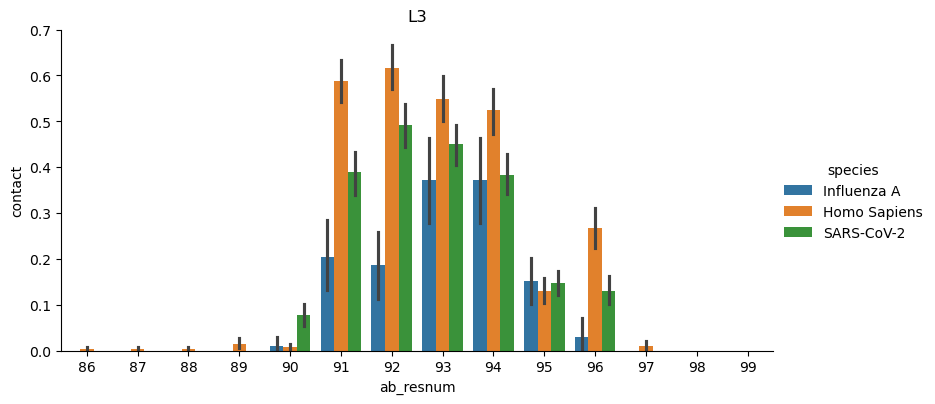

In [14]:
sns.catplot(data = m.query("chain_type == 'light' and 85 < ab_resnum < 100"), 
            x = "ab_resnum", 
            y = "contact",
            kind = "bar",
            hue = "species",
            height = 4, aspect = 2)
plt.title("L3")

Based on the plots above, how would you define the CDR regions?

L1: 27-32
L2: 49-56
L3: 91-96
H1: 26-35
H2: 50-58
H3: 94-102

Now we want to annotate our contact data with these CDRs

In [15]:
def annotate_cdr(chain_type, resnum):
    
    if chain_type == 'heavy':

        if 26 <= resnum <= 35:
            return "H1"
        elif 50 <= resnum <= 58:
            return "H2"
        elif 94 <= resnum <= 102:
            return "H3"
        else:
            return "FR"
        
    elif chain_type == 'light':

        if 27 <= resnum <= 32:
            return "L1"
        elif 49 <= resnum <= 56:
            return "L2"
        elif 91 <= resnum <= 96:
            return "L3"
        else:
            return "FR"

Here we need `apply(lambda x: ..., axis = 1)` as we want to pass the whole rows as `x`, not columns.  

In [16]:
m["CDR"] = m.apply(lambda x: annotate_cdr(x["chain_type"], x["ab_resnum"]), axis = 1)

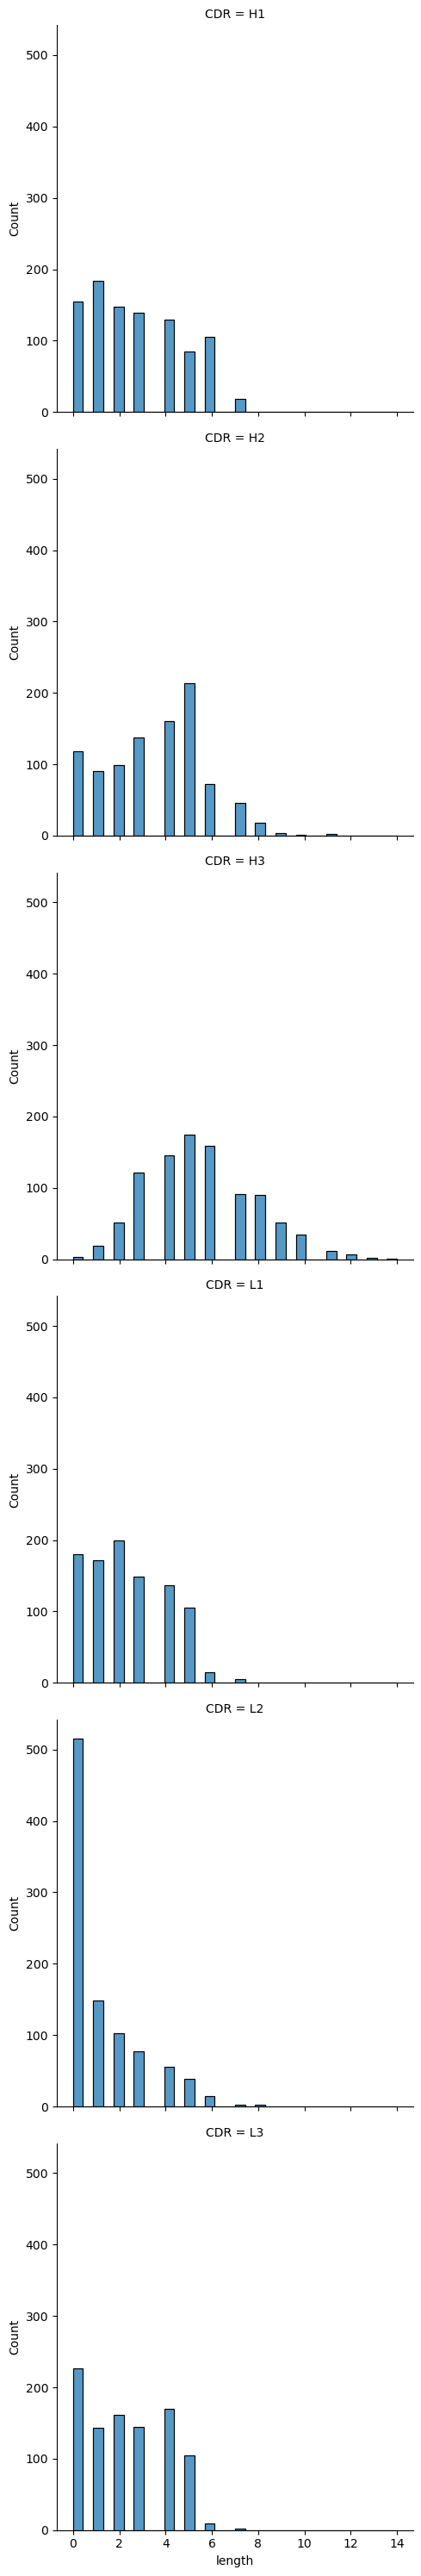

In [17]:
cdrsizes = (m
 .groupby(["pdb_id", "CDR"])
 .agg(length = ("contact", "sum"))
 .reset_index()
)

sns.displot(cdrsizes.query("CDR!='FR'"), 
            x = "length", 
            row = "CDR", 
            kind = "hist") #cdrsizes

H26-28 show much increased contact propensity for SArs vs others. What is the amino acid distribution?

Text(0.5, 1.0, 'number of residues at heavy chain 26-28')

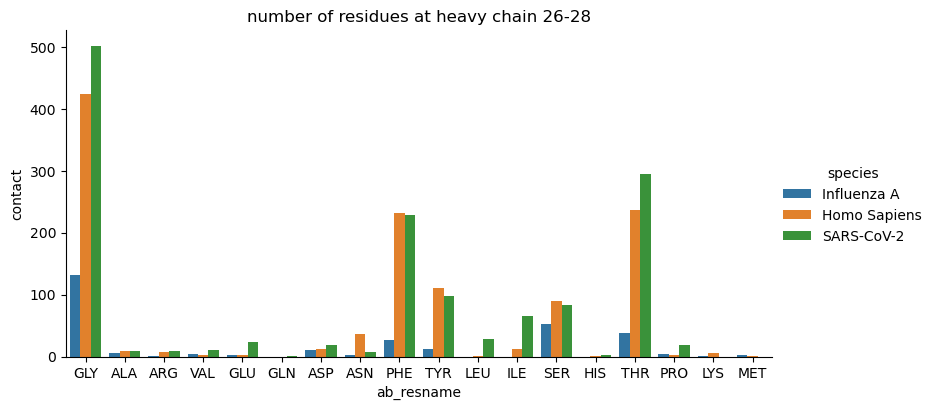

In [18]:
sns.catplot(m.query("CDR == 'H1' and 26 <= ab_resnum <= 28"),
            x = "ab_resname",
            y = "contact",
            hue = "species",
            kind = "bar",
            estimator = "size",
            height = 4, aspect = 2)
plt.title("number of residues at heavy chain 26-28")

Text(0.5, 1.0, 'mean contact fraction at heavy chain 26-28')

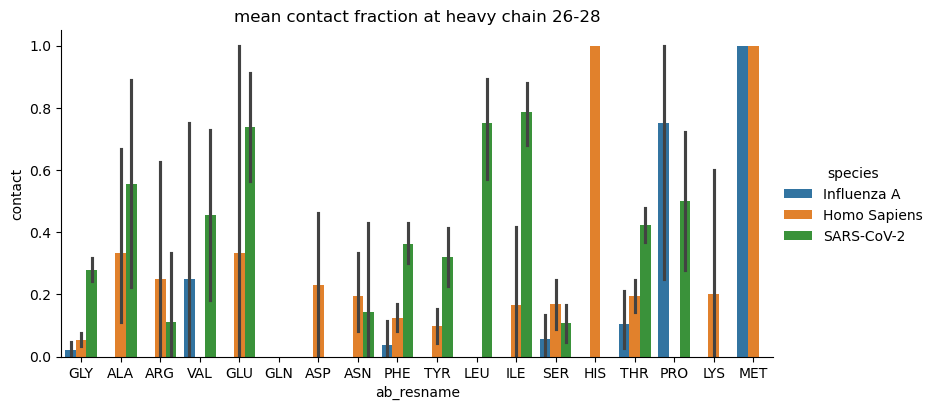

In [19]:
sns.catplot(m.query("CDR == 'H1' and 26 <= ab_resnum <= 28"),
            x = "ab_resname",
            y = "contact",
            hue = "species",
            kind = "bar",
            estimator = "mean",
            height = 4, aspect = 2)

plt.title("mean contact fraction at heavy chain 26-28")

### Amino acid composition of CDR residues

In [20]:
aacounts = (m
            .query("CDR in ['H1', 'H2', 'H3']")
            .groupby(["ab_resnum", "ab_resname", "CDR"])
            .size()
            .unstack("ab_resname")
            .fillna(0))

#aacounts["freq"] = aacounts.groupby("ab_resnum")["count"].transform(lambda x: x / x.sum())
freq_prop =aacounts.div(aacounts.sum(axis=1), axis=0)

<Axes: xlabel='ab_resnum-CDR', ylabel='ab_resname'>

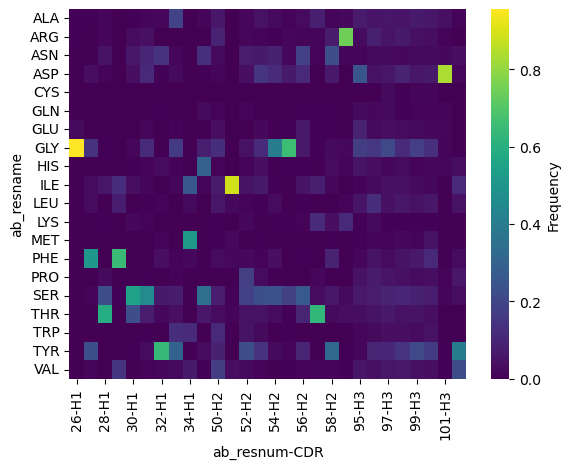

In [21]:
sns.heatmap(freq_prop.T, cmap="viridis", cbar_kws={"label": "Frequency"})

### Contact propensity of amino acids by antigen species



To check differences in contact propensity of amino acids by antigen species, we use a barplot (`catplot(..., kind = "bar")`)


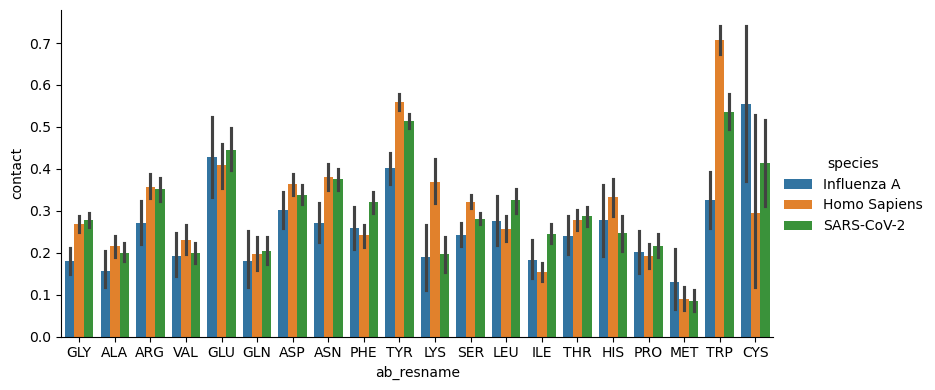

In [22]:
sns.catplot(data = m.query("CDR != 'FR'"), 
            x = "ab_resname", 
            y = "contact",
            hue = "species",
            errorbar = ("ci", 95),
            kind = "bar",
            height = 4, aspect = 2)

We can observe clear differences between the species. But we need to validate that using a statistical test. The appropriate statistical test for a barplot is the chisquare test.

The chisquare test requires a contingency table as input.

The table has one row per ab_resname, and six columns (ncontacts and nnoncontacts for each species).


In [23]:
m.head(3).T

,0,128,233
pdb_id,8veb,8veb,8ved
chain_type,heavy,light,heavy
ab_chain,G,I,H
ab_resnum,1,1,1
ab_icode,,,
ab_resname,GLN,ASP,GLN
natomcontacts,0.0,0.0,0.0
nrescontacts,0.0,0.0,0.0
contact,0.0,0.0,0.0
pdb,8veb,8veb,8ved


In [24]:
tbl = (m
       .query("CDR != 'FR'"))

tbl = pd.crosstab(tbl["ab_resname"], [tbl["contact"], tbl["species"]])

In [25]:
tbl

contact             0.0                                 1.0              \
species    Homo Sapiens Influenza A SARS-CoV-2 Homo Sapiens Influenza A   
ab_resname                                                                
ALA                 848         214       1017          233          40   
ARG                 632         218        740          352          81   
ASN                 723         284        881          443         105   
ASP                 877         293       1157          499         127   
CYS                  12          12         51            5          15   
GLN                 358         104        504           88          23   
GLU                 200          60        214          138          45   
GLY                1592         510       2009          583         112   
HIS                 297          86        336          148          33   
ILE                 886         242       1049          160          54   
LEU                 568         160        680          195          61   
LYS                 208          73        280          121          17   
MET                 343          67        405           34          10   
PHE                 841         194        826          268          68   
PRO                 621         194        697          148          49   
SER                2319         709       3188         1099         228   
THR                1029         271       1186          396          85   
TRP                 174         122        262          422          59   
TYR                1258         401       1536         1591         270   
VAL                 476         173        828          143          41   

contact                
species    SARS-CoV-2  
ab_resname             
ALA               255  
ARG               400  
ASN               528  
ASP               591  
CYS                36  
GLN               130  
GLU               172  
GLY               772  
HIS               110  
ILE               341  
LEU               327  
LYS                69  
MET                37  
PHE               390  
PRO               192  
SER              1244  
THR               477  
TRP               303  
TYR              1625  
VAL               206

In [26]:
from scipy.stats import chi2_contingency
chi2_stat, p, dof, expected = chi2_contingency(tbl.to_numpy())

chi2_stat, p, dof

(3316.4948354433186, 0.0, 95)

As expected, the difference is highly significant (p-value given as 0, so it is very small).


Now let's test single amino acids. Here we need to pass in a contingency table for a given amino acid.

In [27]:
tbl2 = (m
       .query("CDR != 'FR'"))

tbl2 = pd.crosstab([tbl2["ab_resname"], tbl2["species"]], tbl2["contact"])

tbl2.head()

contact                   0.0  1.0
ab_resname species                
ALA        Homo Sapiens   848  233
           Influenza A    214   40
           SARS-CoV-2    1017  255
ARG        Homo Sapiens   632  352
           Influenza A    218   81

If we only pass the outer index to `.loc`, we get a data frame with the inner index as desired.

In [28]:
tbl2.loc["GLN"]

contact,0.0,1.0
species,,
Homo Sapiens,358,88
Influenza A,104,23
SARS-CoV-2,504,130


In [29]:
from scipy.stats import chi2_contingency
chi2_stat, p, dof, expected = chi2_contingency(tbl2.loc["GLN"].to_numpy())

chi2_stat, p, dof

(0.40426448838845924, 0.8169868790264602, 2)

### Propensity of amino acid contacts by chain type

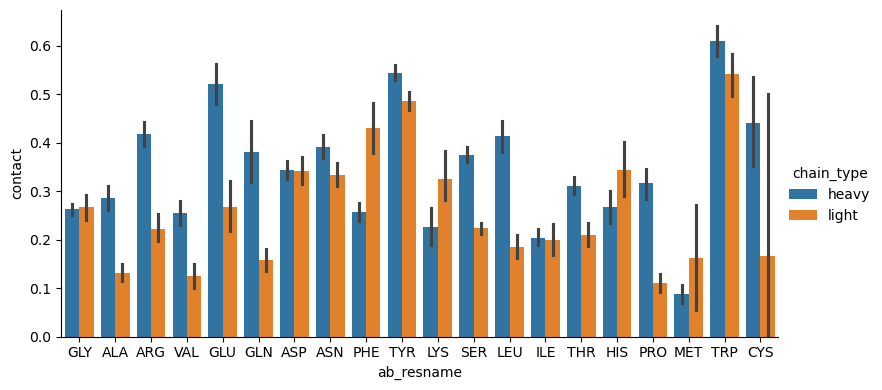

In [30]:
sns.catplot(data = m.query("CDR != 'FR'"), 
            x = "ab_resname", 
            y = "contact",
            hue = "chain_type",
            kind = "bar",
            estimator = "mean",
            height = 4, aspect = 2)

Test for significant differences in amino acid contact propensity between heavy and light chains using a chisquare test.

In [31]:
tbl = m.query("CDR != 'FR'")
tbl = pd.crosstab(tbl["ab_resname"], [tbl["chain_type"], tbl["contact"]])
tbl

chain_type heavy       light      
contact      0.0   1.0   0.0   1.0
ab_resname                        
ALA          861   344  1218   184
ARG          874   628   716   205
ASN          923   593   965   483
ASP         1597   837   730   380
CYS           70    55     5     1
GLN          138    85   828   156
GLU          252   274   222    81
GLY         3238  1150   873   317
HIS          534   194   185    97
ILE         1660   426   517   129
LEU          554   389   854   194
LYS          335    98   226   109
MET          784    75    31     6
PHE         1655   570   206   156
PRO          595   275   917   114
SER         2504  1503  3712  1068
THR         1615   728   871   230
TRP          332   518   226   266
TYR         1861  2222  1334  1264
VAL          906   309   571    81

In [32]:
from scipy.stats import chi2_contingency
chi2_stat, p, dof, expected = chi2_contingency(tbl.to_numpy())
print(f"Chi2 = {chi2_stat:.2f}, p = {p:.4g}, df = {dof}")

Chi2 = 8731.70, p = 0, df = 57


### Principal component analysis

We want to do a principal component analysis of pdb_ids. We can represent each pdb_id by a multi-dimensional feature vector. As it is hard to visualize points in high dimensions, we apply PCA as a dimension reduction technique.

So we need a matrix with pdb_ids as rows and features as columns.

As features we choose the number of contacts per residue type.
We, therefore, need to group by pdb_id and ab_resname.


In [33]:
p = m.query("CDR != 'FR' and contact == 1")

p = pd.crosstab([p["pdb_id"], p["CDR"], p["species"], p["method"]], p["ab_resname"])

p.head(3)

ab_resname                                 ALA  ARG  ASN  ASP  CYS  GLN  GLU  \
pdb_id CDR species      method                                                 
1adq   H1  Homo Sapiens X-RAY DIFFRACTION    0    0    0    1    0    0    0   
       H2  Homo Sapiens X-RAY DIFFRACTION    0    0    0    0    0    0    0   
       H3  Homo Sapiens X-RAY DIFFRACTION    0    1    0    0    0    0    0   

ab_resname                                 GLY  HIS  ILE  LEU  LYS  MET  PHE  \
pdb_id CDR species      method                                                 
1adq   H1  Homo Sapiens X-RAY DIFFRACTION    0    0    0    0    0    0    0   
       H2  Homo Sapiens X-RAY DIFFRACTION    0    0    0    0    0    0    0   
       H3  Homo Sapiens X-RAY DIFFRACTION    0    0    0    0    0    0    0   

ab_resname                                 PRO  SER  THR  TRP  TYR  VAL  
pdb_id CDR species      method                                           
1adq   H1  Homo Sapiens X-RAY DIFFRACTION    0    0    0    0    0    0  
       H2  Homo Sapiens X-RAY DIFFRACTION    0    0    0    1    0    0  
       H3  Homo Sapiens X-RAY DIFFRACTION    0    1    0    0    1    1

In [34]:
p = m.query("CDR in ['H1', 'H2', 'H3'] and contact == 1")

p = pd.crosstab([p["pdb_id"], p["species"], p["method"]], p["ab_resnum"])

p.head(3)

,,ab_resnum,26,27,28,29,30,31,32,33,34,35,...,58,94,95,96,97,98,99,100,101,102
pdb_id,species,method,,,,,,,,,,,,,,,,,,,,,
1adq,Homo Sapiens,X-RAY DIFFRACTION,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,1,1,1,0,0,0
1h0d,Homo Sapiens,X-RAY DIFFRACTION,0,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,1,0,1,0,0
1i9r,Homo Sapiens,X-RAY DIFFRACTION,0,0,0,0,0,1,1,1,0,0,...,1,0,0,0,1,1,1,0,0,0


In [35]:
metadata = p.index.to_frame(index = False)
metadata

,pdb_id,species,method
0,1adq,Homo Sapiens,X-RAY DIFFRACTION
1,1h0d,Homo Sapiens,X-RAY DIFFRACTION
2,1i9r,Homo Sapiens,X-RAY DIFFRACTION
3,1iqd,Homo Sapiens,X-RAY DIFFRACTION
4,1jps,Homo Sapiens,X-RAY DIFFRACTION
...,...,...,...
954,9goy,Homo Sapiens,X-RAY DIFFRACTION
955,9gwt,Homo Sapiens,X-RAY DIFFRACTION
956,9l1s,Homo Sapiens,ELECTRON MICROSCOPY
957,9mer,Influenza A,X-RAY DIFFRACTION


In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(p.to_numpy())  # center & scale
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

In [37]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3", "PC4", "PC5"])

df_pca = pd.concat([df_pca, metadata], axis=1)

df_pca.head(3)


,PC1,PC2,PC3,PC4,PC5,pdb_id,species,method
0,-0.782708,-1.682613,1.061303,-0.636396,2.010517,1adq,Homo Sapiens,X-RAY DIFFRACTION
1,-1.355937,2.840742,0.137843,-0.652484,-0.210619,1h0d,Homo Sapiens,X-RAY DIFFRACTION
2,0.303227,1.791163,-1.000710,1.180460,1.656791,1i9r,Homo Sapiens,X-RAY DIFFRACTION


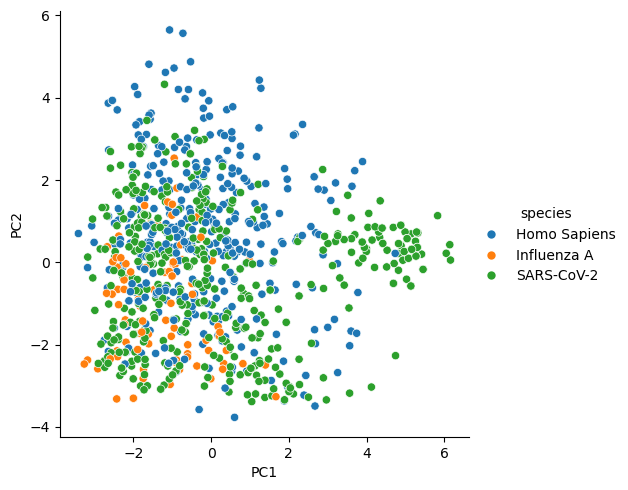

In [38]:
sns.relplot(data=df_pca, x="PC1", y="PC2", hue = "species")

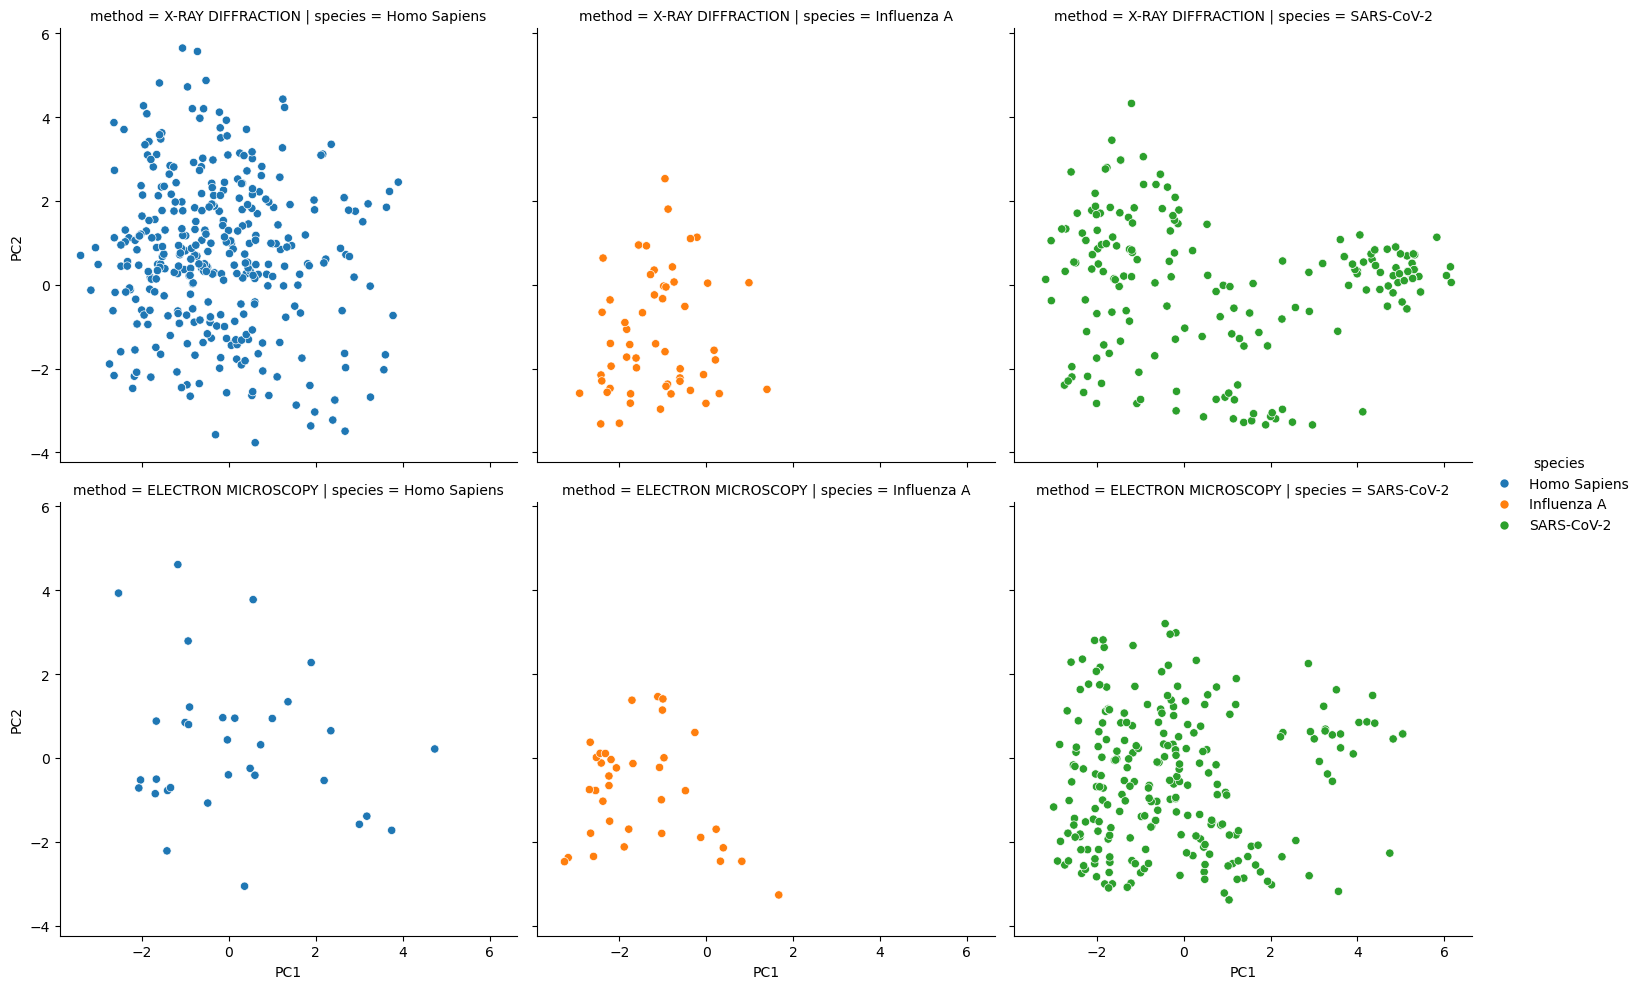

In [39]:
sns.relplot(data=df_pca, x="PC1", y="PC2", hue = "species", col = "species", row = "method")

SARS shows two clusters, PC1 < 4 and PC1 > 4. Cluster for PC1 > 4 is specific to SARS. How do they differ?

Look at the loadings of PC1 (the features that contribute to PC1)

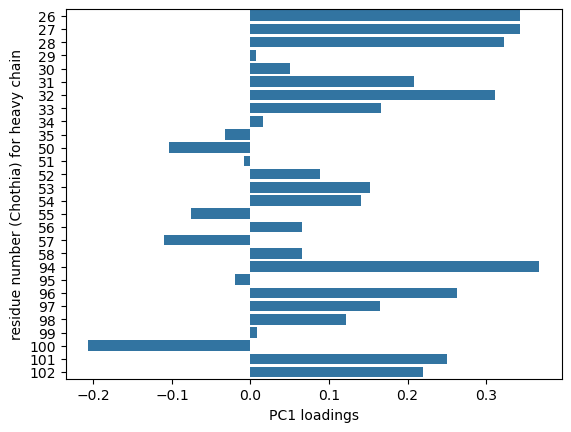

In [40]:
pc1_loadings = pd.Series(pca.components_[0], index = p.columns)
sns.barplot(pc1_loadings, orient="y")
plt.ylabel("residue number (Chothia) for heavy chain")
plt.xlabel("PC1 loadings")
plt.show()

We can see that the residues that have the most influence on PC1 are 26, 27, 28, 32, and 94. (we only looked at H1, H2, H3). We had identified 26-28 as specific to SARS-CoV-2 before.

Let's try to create a heatmap of p ordered by PC1

<Axes: >

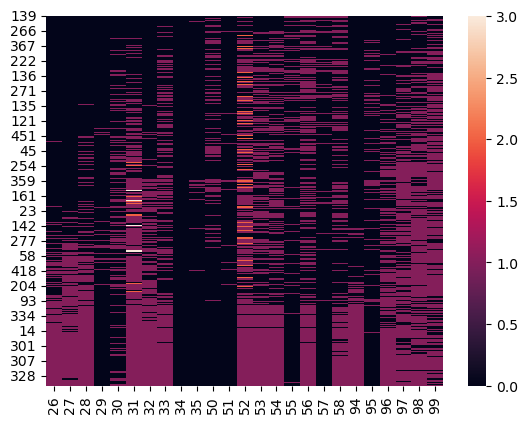

In [41]:
tmp = (p
 .reset_index()
 .query("species == 'SARS-CoV-2'")
 .merge(df_pca.get(["pdb_id", "PC1"]), how = "inner", on = "pdb_id")
 .sort_values("PC1"))

sns.heatmap(tmp.loc[:,26:99])



So we can see that structures with large PC1 (bottom of plot) have sharp difference in contacts ar residue numbers  26-28 and 32 and 94, as indicated by the high PC1 loadings.

Residue 100 has very high contact numbers (is this due to Chotia numbering. i.e. many insertions at 100?)

So maybe we should make a plot for 26:99 only to better see the differences?)

### Correlation between contact fraction in CDRs

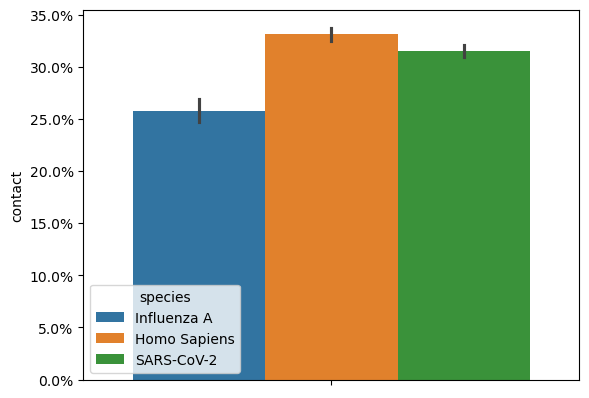

In [42]:
#sns.barplot(m.query("CDR != 'FR'"), 
            #x = "CDR", 
            #y = "contact", hue = "species")

import matplotlib.ticker as mtick

m_plot = m.query("CDR != 'FR'").copy()
m_plot['contact'] = m_plot['contact'] * 100

ax = sns.barplot(data=m_plot, y="contact", hue="species")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

<Axes: xlabel='CDR', ylabel='contact'>

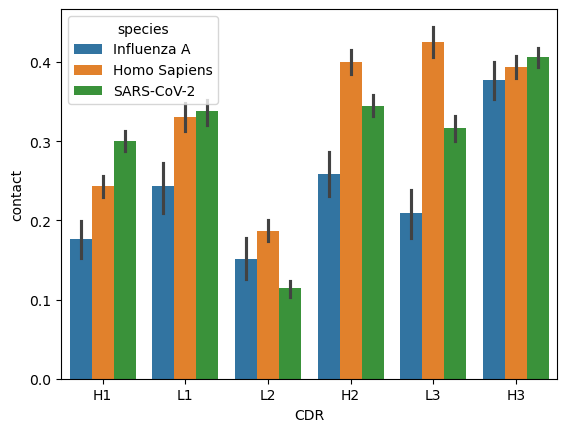

In [43]:
sns.barplot(m.query("CDR != 'FR'"), 
            x = "CDR", 
            y = "contact", hue = "species")

In [44]:
cpw = (m
.query("CDR != 'FR'")
.groupby(["pdb_id", "species", "method", "CDR"])
.agg(cp = ("contact", "mean"))
.unstack("CDR")
.get("cp")
)

cpw

,,CDR,H1,H2,H3,L1,L2,L3
pdb_id,species,method,,,,,,
1adq,Homo Sapiens,X-RAY DIFFRACTION,0.10,0.100000,0.266667,0.000000,0.250,0.000000
1h0d,Homo Sapiens,X-RAY DIFFRACTION,0.10,0.600000,0.230769,0.300000,0.000,0.833333
1i9r,Homo Sapiens,X-RAY DIFFRACTION,0.30,0.600000,0.300000,0.300000,0.000,0.500000
1iqd,Homo Sapiens,X-RAY DIFFRACTION,0.60,0.600000,0.444444,0.428571,0.375,0.833333
1jps,Homo Sapiens,X-RAY DIFFRACTION,0.40,0.500000,0.333333,0.166667,0.125,0.833333
...,...,...,...,...,...,...,...,...
9goy,Homo Sapiens,X-RAY DIFFRACTION,0.00,0.400000,0.266667,0.000000,0.000,0.666667
9gwt,Homo Sapiens,X-RAY DIFFRACTION,0.20,0.333333,0.454545,0.400000,0.125,0.833333
9l1s,Homo Sapiens,ELECTRON MICROSCOPY,0.50,0.500000,0.363636,0.000000,0.500,0.000000


Can do pairplots with regression lines

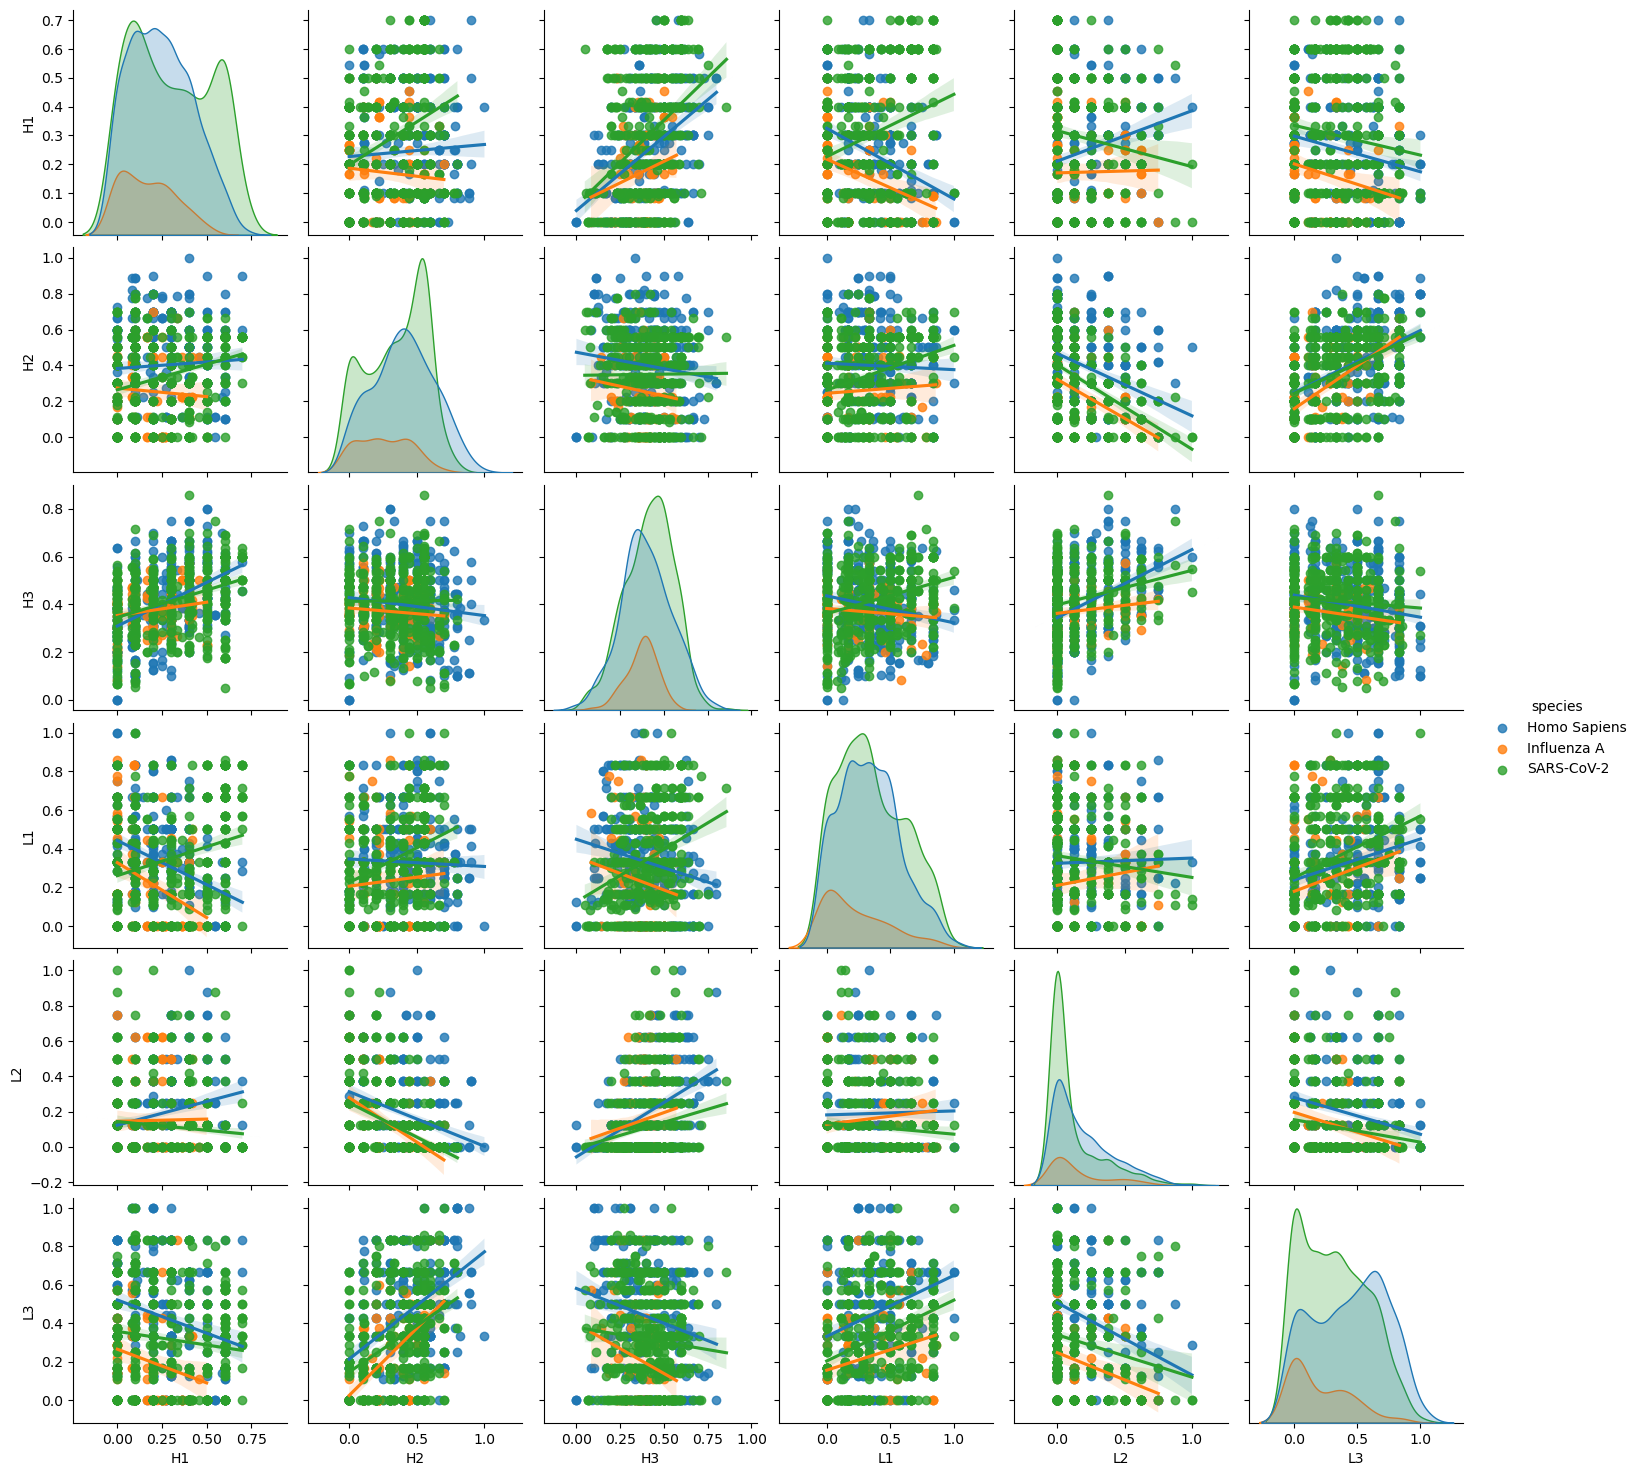

In [45]:
sns.pairplot(cpw.reset_index(), 
             vars = ["H1", "H2", "H3", "L1", "L2", "L3"], 
             kind = "reg", 
             hue = "species")

Negative correlations are interesting. Might indicate compensation mechanisms.

We can do a scatter plot with linear regression fit using `sns.lmplot`

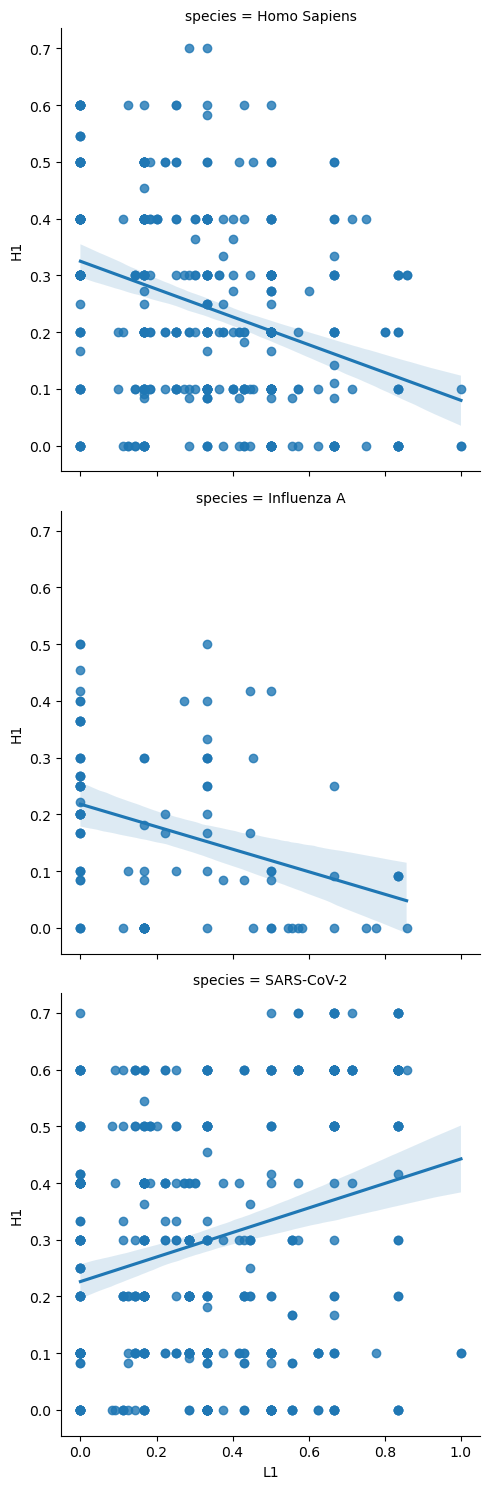

In [46]:
sns.lmplot(cpw.reset_index(), x = "L1", y = "H1", row = 'species')

If we see something interestin, need to test it. Here we test correlation between H2 and L2

In [47]:
import statsmodels.formula.api as smf

model = smf.ols("H1 ~ L1", data = cpw.query("species == 'Homo Sapiens'").reset_index()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     H1   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     49.66
Date:                Thu, 03 Jul 2025   Prob (F-statistic):           8.24e-12
Time:                        17:04:54   Log-Likelihood:                 158.46
No. Observations:                 396   AIC:                            -312.9
Df Residuals:                     394   BIC:                            -305.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3249      0.014     22.968      0.000       0.297       0.353
L1            -0.2452      0.035     -7.047      0.000      -0.314      -0.177
==============================================================================
Omnibus:                       13.066   Durbin-Watson:                   1.811
Prob(Omnibus):                  0.001   Jarque-Bera (JB):                8.365
Skew:                           0.210   Prob(JB):                       0.0153
Kurtosis:                       2.425   Cond. No.                         4.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
import statsmodels.formula.api as smf

model = smf.ols("H2 ~ L2+L3", data = cpw.reset_index()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     H2   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     194.0
Date:                Thu, 03 Jul 2025   Prob (F-statistic):           1.82e-71
Time:                        17:04:54   Log-Likelihood:                 247.18
No. Observations:                 960   AIC:                            -488.4
Df Residuals:                     957   BIC:                            -473.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2910      0.011     25.620      0.000       0.269       0.313
L2            -0.3011      0.030    -10.173      0.000      -0.359      -0.243
L3             0.3257      0.022     14.764      0.000       0.282       0.369
==============================================================================
Omnibus:                        7.828   Durbin-Watson:                   1.745
Prob(Omnibus):                  0.020   Jarque-Bera (JB):                5.702
Skew:                           0.054   Prob(JB):                       0.0578
Kurtosis:                       2.638   Cond. No.                         5.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

95% CI for slope of L2 is [-0.473, -0.318], significantly negative correlation (p given as 0.000, i.e. p < 5e-4)

In [49]:
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2910,0.011,25.620,0.000,0.269,0.313
L2,-0.3011,0.030,-10.173,0.000,-0.359,-0.243
L3,0.3257,0.022,14.764,0.000,0.282,0.369
